# Hypersonic Wing — Thermal Loads and Buckling

This notebook studies high-speed wing-skin sizing with aerodynamic heating, thermal resultants, and buckling checks across Mach 0.8 to Mach 5.

**Material note:** IM7/8552 has a practical service limit of ~150°C (Tg ~230°C, matrix degrades above cure temperature 177°C). At Mach 5 / 20 km, the adiabatic wall temperature is ~912°C — the epoxy matrix would be completely decomposed. The M5.0 cases are included to demonstrate the *mechanics* of thermal load entry into the optimizer, not to represent a realistic IM7/8552 design. In practice, a ceramic matrix composite (CMC) or a TPS-protected metallic structure would be required at these temperatures.

Topics:
- `WingGeometry` and `wing_panel_loads` for spanwise load distributions
- Adiabatic wall temperature and why it matters above Mach 3
- Thermal resultants: how delta-T loads enter the Tsai-Wu check
- Buckling RF and when it overtakes the strength constraint
- Mass penalty breakdown across five Mach cases

In [1]:
import sys, os
from pathlib import Path

# Resolve repo root regardless of where Jupyter was launched from
_nb_dir = Path(os.path.abspath("")).resolve()
_repo_root = _nb_dir.parent if _nb_dir.name == "notebooks" else _nb_dir
sys.path.insert(0, str(_repo_root / "src"))

import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from composite_panel import (
    IM7_8552, IM7_8552_thermal,
    WingGeometry, wing_panel_loads,
    aero_wall_temperature, equilibrium_wall_temperature,
    thermal_state_from_flight, thermal_resultants,
    Ply, Laminate,
    Nxx_cr, buckling_rf,
)
from composite_panel.optimizer import (
    optimize_wing, detect_balance_pairs,
    WingOptimizationResult,
)

---
## 1. Wing Geometry

`WingGeometry` defines a trapezoidal planform. The key parameters and what they control:

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `semi_span` | 4.5 m | Distance from root to tip |
| `root_chord` | 4.0 m | Chord length at the root |
| `taper_ratio` | 0.25 | tip_chord / root_chord |
| `sweep_le_deg` | 50deg | Leading-edge sweep |
| `t_over_c` | 0.04 | Thickness-to-chord ratio (thin section) |
| `mtow_n` | 120 kN | Max take-off weight |


In [2]:
wing = WingGeometry(
    semi_span    = 4.5,
    root_chord   = 4.0,
    taper_ratio  = 0.25,
    sweep_le_deg = 50.0,
    t_over_c     = 0.04,
    mtow_n       = 120_000.0,
)

# Show how chord varies with span station eta = y/(b/2)
etas = np.linspace(0, 1, 11)
print('Spanwise chord distribution:')
print(f'  {"eta":>6}  {"chord [m]":>10}')
for e in etas:
    print(f'  {e:>6.2f}  {wing.chord(e):>10.3f}')

Spanwise chord distribution:
     eta   chord [m]
    0.00       4.000
    0.10       3.700
    0.20       3.400
    0.30       3.100
    0.40       2.800
    0.50       2.500
    0.60       2.200
    0.70       1.900
    0.80       1.600
    0.90       1.300
    1.00       1.000


---
## 2. Material: Mechanical and Thermal Properties

At hypersonic speeds the skin heats up significantly. We need two material objects:

- `IM7_8552()`  --  standard elastic/strength properties for Tsai-Wu failure and stiffness calculations
- `IM7_8552_thermal()`  --  adds coefficients of thermal expansion (CTE) and cure temperature, needed to compute thermal running loads

The **cure temperature** is critical. IM7/8552 cures at ~177degC. After cure, the panel is stress-free at that temperature. In service, if the wall temperature exceeds the cure temperature, the cured-in compressive residual stresses become tensile  --  potentially reducing the effective RF.

In [3]:
mat = IM7_8552()          # elastic + strength
pt  = IM7_8552_thermal()  # adds CTE, cure temp

print('Elastic properties:', mat)
print()
print(f'Cure temperature: {pt.T_cure - 273.15:.0f} C')
print(f'CTE fibre direction (alpha1): {pt.alpha_1*1e6:.2f} ppm/K')
print(f'CTE transverse (alpha2):      {pt.alpha_2*1e6:.2f} ppm/K')

Elastic properties: PlyMaterial(E1=171400000000.0, E2=9080000000.0, G12=5290000000.0, nu12=0.32, F1t=2326000000.0, F1c=1200000000.0, F2t=62000000.0, F2c=200000000.0, F12=90000000.0, name='IM7/8552')

Cure temperature: 177 C
CTE fibre direction (alpha1): 0.30 ppm/K
CTE transverse (alpha2):      28.80 ppm/K


---
## 3. Adiabatic Wall Temperature 

At high speeds, aerodynamic heating raises the skin temperature. Two related temperatures:

**Adiabatic wall temperature** (`T_aw`)  --  the equilibrium temperature of an insulated (zero-heat-flux) surface. It depends only on Mach and altitude:

$$T_{aw} = T_{\infty} \left(1 + r \cdot \frac{\gamma - 1}{2} M^2\right)$$

where `r ~= 0.85` is the turbulent recovery factor.

**Equilibrium wall temperature** (`T_eq`)  --  the temperature of a real (heat-conducting, radiating) surface. It also depends on the wetted length `x` from the leading edge because laminar/turbulent transition changes the heat transfer coefficient.

IM7/8552 has a practical service limit around 120-150degC. At Mach 5 / 20 km, `T_aw` typically exceeds 600degC  --  far above the matrix glass transition temperature. In practice you would use a ceramic matrix composite or a thermal protection system, but this demo shows what the mechanical sizing looks like when you include the thermal stress terms.

In [4]:
alt_m = 20_000   # flight altitude [m]

machs = [0.8, 1.7, 2.4, 5.0]
print(f'Adiabatic wall temperatures at {alt_m/1e3:.0f} km:')
print(f'  {"Mach":>6}  {"T_aw [C]":>10}  {"T_aw [K]":>10}')
for m in machs:
    T = aero_wall_temperature(m, alt_m)
    print(f'  {m:>6.1f}  {T-273.15:>10.1f}  {T:>10.1f}')

print(f'\nIM7/8552 cure temp: {pt.T_cure - 273.15:.0f} C  |  practical service limit ~150 C')
print(f'  T_aw at M2.4 ({aero_wall_temperature(2.4,alt_m)-273.15:.0f} C) already exceeds cure temp')
print(f'  T_aw at M5.0 ({aero_wall_temperature(5.0,alt_m)-273.15:.0f} C) far above matrix decomposition — pedagogical only')

Adiabatic wall temperatures at 20 km:
    Mach    T_aw [C]    T_aw [K]
     0.8       -30.8       242.4
     1.7        56.3       329.5
     2.4       167.5       440.6
     5.0       912.6      1185.7

IM7/8552 cure temp: 177 C  |  practical service limit ~150 C
  T_aw at M2.4 (167 C) already exceeds cure temp
  T_aw at M5.0 (913 C) far above matrix decomposition — pedagogical only


---
## 4. How `thermal_resultants` Works

When the laminate temperature changes by `delta_T` from cure temperature, each ply tries to expand/contract according to its CTE. Because adjacent plies are bonded and have different orientations, they constrain each other  --  generating **thermal running loads** `N_T`.

$$N_T = \sum_k \bar{Q}^{(k)} \cdot \alpha^{(k)} \cdot \Delta T \cdot t_k$$

These `N_T` loads are added to the aerodynamic running loads before the Tsai-Wu check. At Mach 5, `delta_T` can be several hundred Kelvin, producing `N_T` values comparable to the mechanical loads.

In [5]:
# Example: compute thermal resultants at the mid-span station, Mach 5
eta_mid  = 0.45
x_c_mid  = 0.4 * wing.chord(eta_mid)   # 40% chord location from leading edge
ts_mid   = thermal_state_from_flight(5.0, alt_m, x_c_mid)

print(f'Thermal state at mid-span (eta={eta_mid}, x={x_c_mid:.2f}m):')
print(f'  T_wall  = {ts_mid.T_wall_outer - 273.15:.1f} C  (>> IM7/8552 service limit)')
print(f'  T_cure  = {pt.T_cure - 273.15:.1f} C')
print(f'  delta_T = {ts_mid.T_wall_outer - pt.T_cure:.1f} K')

# Build a representative laminate to evaluate thermal resultants
angles   = [0.0, 45.0, -45.0, 90.0]
ang_full = angles + list(reversed(angles))
n_ply    = len(ang_full)
t_demo   = 0.125e-3   # nominal ply thickness for illustration
plies_ex = [Ply(mat, t_demo, a) for a in ang_full]
lam_ex   = Laminate(plies_ex)

nt, _ = thermal_resultants(lam_ex.plies, [pt]*n_ply, ts_mid, lam_ex.z_interfaces)
print(f'\nThermal running loads N_T [kN/m]:')
print(f'  NT_xx = {nt[0]/1e3:+.1f} kN/m')
print(f'  NT_yy = {nt[1]/1e3:+.1f} kN/m')
print(f'  NT_xy = {nt[2]/1e3:+.1f} kN/m')

Thermal state at mid-span (eta=0.45, x=1.06m):
  T_wall  = 594.4 C  (>> IM7/8552 service limit)
  T_cure  = 177.0 C
  delta_T = 417.4 K

Thermal running loads N_T [kN/m]:
  NT_xx = +66.7 kN/m
  NT_yy = +66.7 kN/m
  NT_xy = -0.0 kN/m


---
## 5. Buckling Reserve Factor

Thin panels under compression can buckle before the material reaches its strength limit. The critical buckling load for a simply-supported orthotropic plate is:

$$N_{xx}^{cr} = \frac{\pi^2}{b^2} \left[ D_{11} \left(\frac{b}{a}\right)^2 m^2 + 2(D_{12} + 2D_{66}) + D_{22} \left(\frac{a}{b}\right)^2 \frac{1}{m^2} \right]$$

where `m` is the number of half-waves (minimised over m=1,2,...), `a` is the panel length (span), `b` is the panel width (chord), and `D` is the bending stiffness matrix.

The **buckling RF** is simply `N_cr / N_applied`. A thin, lightly-loaded panel may pass Tsai-Wu with RF > 1.5 but still buckle (buckling RF < 1). Adding the buckling constraint forces the optimizer to use a thicker laminate (larger D-matrix), which can significantly increase mass.

In [6]:
panel_a = 0.50   # rib pitch [m]
panel_b = 0.20   # stringer pitch [m]

# Show how buckling RF varies with laminate thickness for a fixed load
n_demo   = np.array([-150e3, -30e3, 10e3])   # representative panel load [N/m]
n_plies_range = [4, 6, 8, 10, 12, 16]

print(f'Buckling RF vs laminate thickness (Nxx={n_demo[0]/1e3:.0f} kN/m):')
print(f'  {"n_plies":>8}  {"h [mm]":>8}  {"RF_buckle":>10}')
for np_ in n_plies_range:
    angs = ([0, 45, -45, 90] * (np_ // 4))[:np_]
    pl   = [Ply(mat, t_demo, a) for a in angs]
    lm   = Laminate(pl)
    rf_b = buckling_rf(n_demo, lm.D, panel_a, panel_b)
    print(f'  {np_:>8d}  {lm.thickness*1e3:>8.3f}  {rf_b:>10.3f}')

Buckling RF vs laminate thickness (Nxx=-150 kN/m):
   n_plies    h [mm]   RF_buckle
         4     0.500       0.003
         6     0.500       0.003
         8     1.000       0.024
        10     1.000       0.024
        12     1.500       0.084
        16     2.000       0.199


---
## 6. Full Wing Optimisation  --  All Five Cases

`optimize_wing` runs the laminate optimiser at `N_STATIONS` span stations for a given Mach/altitude, collecting loads, running the NLP, and assembling total skin mass.

The optimizer variables are the ply thicknesses `t_half` (one per unique angle in the half-stack). Constraints:
- Tsai-Wu RF >= `rf_min` for every ply at every station
- Buckling RF >= `buckle_rf_min` when enabled
- Balance: `t(+theta) == t(-theta)` (enforced via `balance_pairs`)

In [7]:
angles     = [0.0, 45.0, -45.0, 90.0]
pairs      = detect_balance_pairs(angles)
etas       = np.linspace(0.05, 0.95, 12)
alpha_deg  = 3.0
n_load     = 2.5

cases = {
    'M0.8  subsonic':     dict(mach=0.8, use_thermal=False, use_buckling=False),
    'M1.7  supersonic':   dict(mach=1.7, use_thermal=False, use_buckling=False),
    'M2.4  supersonic':   dict(mach=2.4, use_thermal=False, use_buckling=False),
    'M5.0  mech only':    dict(mach=5.0, use_thermal=False, use_buckling=False),
    'M5.0  therm+buckle': dict(mach=5.0, use_thermal=True,  use_buckling=True),
}

results_all = {}

for label, cfg in cases.items():
    mach = cfg['mach']
    print(f'  Sizing: {label} ...')

    ts_list = []
    for eta in etas:
        if cfg['use_thermal']:
            x_c = 0.4 * wing.chord(eta)
            ts_list.append(thermal_state_from_flight(mach, alt_m, x_c))
        else:
            ts_list.append(None)

    result = optimize_wing(
        wing            = wing,
        mach            = mach,
        altitude_m      = alt_m,
        alpha_deg       = alpha_deg,
        mat             = mat,
        angles_half_deg = angles,
        n_load          = n_load,
        n_stations      = len(etas),
        rf_min          = 1.5,
        t_min           = 0.05e-3,
        t_init          = 0.15e-3,
        balance_pairs   = pairs,
        rho_kg_m3       = 1600.0,
        panel_a         = panel_a if cfg['use_buckling'] else None,
        panel_b         = panel_b if cfg['use_buckling'] else None,
        buckle_rf_min   = 1.0,
        thermal_states  = ts_list if cfg['use_thermal'] else None,
        ply_thermal     = pt if cfg['use_thermal'] else None,
    )
    results_all[label] = result

print('\nDone.')

  Sizing: M0.8  subsonic ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=1.30mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 51.04 kg
  Sizing: M1.7  supersonic ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=1.76mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 68.48 kg
  Sizing: M2.4  supersonic ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=1.95mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 75.74 kg
  Sizing: M5.0  mech only ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=2.64mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 101.89 kg
  Sizing: M5.0  therm+buckle ...
  Sizing 12 spanwise stations  --  RF >= 1.5  t_min = 0.05 mm
  [############]  eta=0.95  h=2.87mm  RF=1.501  [OK]
  Upper-skin mass (semi-span): 108.41 kg

Done.


---
## 7. Mass Summary

How much does each flight regime cost in skin mass relative to the M0.8 baseline?

In [8]:
m_base = results_all['M0.8  subsonic'].total_skin_mass
print(f'{"Case":<32}  {"Mass [kg]":>10}  {"vs M0.8":>8}')
print('-' * 58)
for lbl in cases:
    m   = results_all[lbl].total_skin_mass
    pct = (m - m_base) / m_base * 100
    sign = '+' if pct >= 0 else ''
    print(f'{lbl:<32}  {m:>10.1f}  {sign}{pct:>7.0f}%')

Case                               Mass [kg]   vs M0.8
----------------------------------------------------------
M0.8  subsonic                          51.0  +      0%
M1.7  supersonic                        68.5  +     34%
M2.4  supersonic                        75.7  +     48%
M5.0  mech only                        101.9  +    100%
M5.0  therm+buckle                     108.4  +    112%


---
## 8. Visualisation  --  Spanwise Results

Figure saved -> C:\Users\AlexanderAmos\Documents\code\composite_panel\outputs\hypersonic_wing_mdo.png


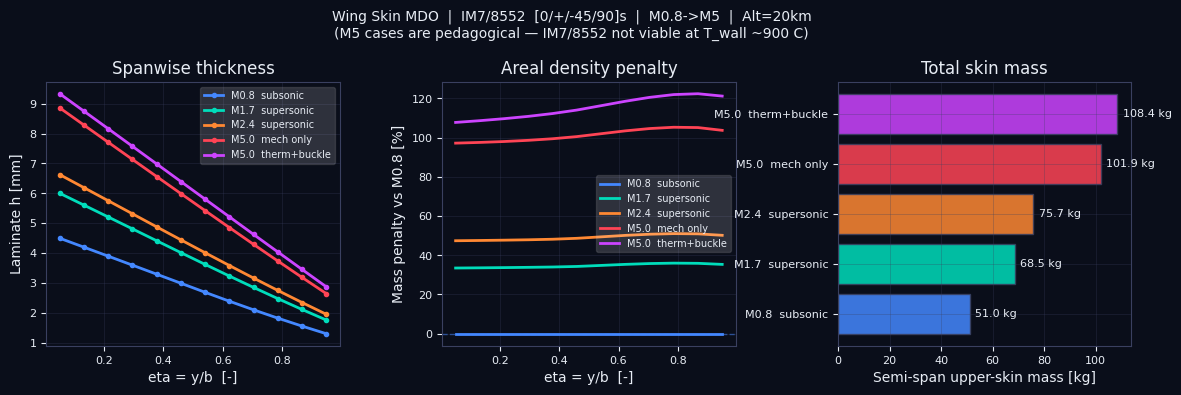

In [9]:
bg    = '#0a0e1a'; white = '#e8edf5'; dim = '#3a4060'
colors_map = {
    'M0.8  subsonic':     '#4488ff',
    'M1.7  supersonic':   '#00ddbb',
    'M2.4  supersonic':   '#ff8833',
    'M5.0  mech only':    '#ff4455',
    'M5.0  therm+buckle': '#cc44ff',
}

def _style(ax, legend=False):
    ax.set_facecolor(bg)
    ax.tick_params(colors=white, labelsize=8)
    ax.xaxis.label.set_color(white); ax.yaxis.label.set_color(white)
    ax.title.set_color(white)
    for sp in ax.spines.values(): sp.set_edgecolor(dim)
    ax.grid(color=dim, linewidth=0.4, alpha=0.5)
    if legend:
        ax.legend(fontsize=7, framealpha=0.15, labelcolor=white)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), facecolor=bg)
fig.suptitle(f'Wing Skin MDO  |  IM7/8552  [0/+/-45/90]s  |  M0.8->M5  |  Alt={alt_m/1e3:.0f}km\n'
             f'(M5 cases are pedagogical — IM7/8552 not viable at T_wall ~900 C)',
             color=white, fontsize=10)
fig.subplots_adjust(wspace=0.35, top=0.80, bottom=0.14)

# Spanwise thickness
ax = axes[0]
for label in cases:
    wr = results_all[label]
    ax.plot(etas, wr.thicknesses * 1e3, color=colors_map[label], lw=2,
            marker='o', ms=3, label=label)
ax.set_xlabel('eta = y/b  [-]'); ax.set_ylabel('Laminate h [mm]')
ax.set_title('Spanwise thickness')
_style(ax, legend=True)

# Areal density penalty vs M0.8
ax = axes[1]
rho_base = results_all['M0.8  subsonic'].areal_densities
for label in cases:
    wr  = results_all[label]
    pct = (wr.areal_densities - rho_base) / rho_base * 100
    ax.plot(etas, pct, color=colors_map[label], lw=2, label=label)
ax.axhline(0, color=colors_map['M0.8  subsonic'], lw=1, ls='--', alpha=0.5)
ax.set_xlabel('eta = y/b  [-]'); ax.set_ylabel('Mass penalty vs M0.8 [%]')
ax.set_title('Areal density penalty')
_style(ax, legend=True)

# Total skin mass bar
ax = axes[2]
lbls   = list(cases.keys())
masses = [results_all[l].total_skin_mass for l in lbls]
clrs   = [colors_map[l] for l in lbls]
bars = ax.barh(lbls, masses, color=clrs, edgecolor=dim, alpha=0.85)
ax.bar_label(bars, fmt='%.1f kg', color=white, fontsize=8, padding=4)
ax.set_xlabel('Semi-span upper-skin mass [kg]')
ax.set_title('Total skin mass')
_style(ax)

out = os.path.join(_repo_root, "outputs", "hypersonic_wing_mdo.png")
plt.savefig(out, dpi=150, bbox_inches="tight", facecolor=bg)
print(f"Figure saved -> {out}")
plt.show()

---
## 9. Wall Temperature vs Span (Mach 5)

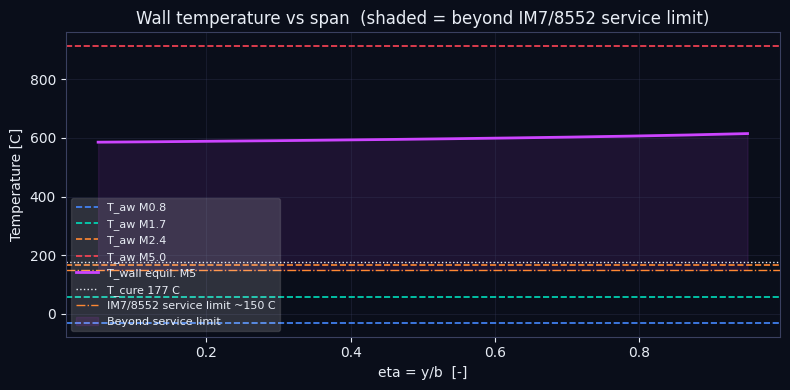

In [10]:
fig, ax = plt.subplots(figsize=(8, 4), facecolor=bg)

t_eq = np.array([
    equilibrium_wall_temperature(5.0, alt_m, x_station=0.4*wing.chord(e))
    for e in etas
])

for m_ref, color, lbl in [(0.8, '#4488ff', 'T_aw M0.8'), (1.7, '#00ddbb', 'T_aw M1.7'),
                           (2.4, '#ff8833', 'T_aw M2.4'), (5.0, '#ff4455', 'T_aw M5.0')]:
    T = aero_wall_temperature(m_ref, alt_m)
    ax.axhline(T - 273.15, color=color, lw=1.2, ls='--', label=lbl)

ax.plot(etas, t_eq - 273.15, color='#cc44ff', lw=2, label='T_wall equil. M5')
ax.axhline(pt.T_cure - 273.15, color=white, lw=1.0, ls=':',
           label=f'T_cure {pt.T_cure-273:.0f} C')
ax.axhline(150, color='#ff8833', lw=1.0, ls='-.',
           label='IM7/8552 service limit ~150 C')
ax.fill_between(etas, 150, t_eq - 273.15, alpha=0.10, color='#cc44ff',
                label='Beyond service limit')

ax.set_xlabel('eta = y/b  [-]', color=white)
ax.set_ylabel('Temperature [C]', color=white)
ax.set_title('Wall temperature vs span  (shaded = beyond IM7/8552 service limit)', color=white)
ax.set_facecolor(bg)
ax.tick_params(colors=white)
for sp in ax.spines.values(): sp.set_edgecolor(dim)
ax.grid(color=dim, lw=0.4, alpha=0.5)
ax.legend(fontsize=8, framealpha=0.15, labelcolor=white)
plt.tight_layout()
plt.show()

---
## 10. Key Takeaways

1. **IM7/8552 is not a hypersonic material.** Its service limit is ~150°C; at Mach 2.4 / 20 km, T_aw already exceeds the cure temperature (177°C). The M5.0 cases (T_wall ~912°C) show how thermal loads enter the optimizer mechanics, not a viable design. Above ~Mach 2.5, a CMC or TPS-protected metallic structure is required in practice.

2. **Mach number drives skin mass non-linearly.** Moving from M0.8 to M2.4 grows mass primarily because dynamic pressure increases (more Nyy). Moving to M5 adds thermal loads on top of even higher dynamic pressure.

3. **Thermal loads at Mach 5 rival mechanical loads.** The equilibrium wall temperature exceeds the cure temperature, flipping the sign of cured-in residual stresses from compressive to tensile. This reduces the margin against transverse (σ₂) tension failure and drives additional thickness.

4. **Buckling is the second-order constraint.** The `M5.0 therm+buckle` case adds more mass than `M5.0 mech only` because the panel must be thick enough for adequate bending stiffness (D-matrix), not just strength. This effect is most pronounced near the root where the panel is widest.

5. **Spanwise thickness tapers root-to-tip.** Bending moments are largest at the root — root stations drive the highest Nxx and need the most material. Tip stations converge toward minimum gauge.